In [52]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

#load data 
filtered_rna = sc.read("/home/fgsasse_lrs_1/Downloads/BA/BA_data/RNA/filtered_Rdata.h5ad")
print(filtered_rna.shape)

gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_10kb.csv")
gene_peaks_10kb.shape

(93063, 32057)


(19380, 2)

## To Anamaria: 
I thought we could exclude the genes that didn't have any known TSS, so we can maybe compare the results also with the other pearson r / lm results. The genes in any window were decreased from 32057 to 19380 genes. So in the next step I included only the genes which were used for the window sizes.

In [51]:
#filtering out the genes not included in the gene-peak assignment file
genes_in_peaks = gene_peaks_10kb['gene_id'].unique()
filtered_rna = filtered_rna[:, filtered_rna.var_names.isin(genes_in_peaks)]
print(f"After filtering, {filtered_rna.n_vars} genes remain for SEACells fitting")

filtered_rna.shape

After filtering, 19380 genes remain for SEACells fitting


(93063, 19380)

#Preprocessing of the data before running SEACells
Again for Anamaria: here I had to do the preprocessing steps to build the kernel.. so I tried all the preprocessing steps with subset of cells, it worked pretty well until I used all cells (93063)

In [39]:
#copy the counts to ".raw" attribute of the anndata since it is necessary for downstream analysis
#this step is performed after filtering the data
raw_filtered_rna = sc.AnnData(filtered_rna.X)
raw_filtered_rna.obs_names, raw_filtered_rna.var_names = filtered_rna.obs_names, filtered_rna.var_names
filtered_rna.raw = raw_filtered_rna


In [40]:
#Normalize cells, log-transform, and identify highly variable genes
sc.pp.normalize_per_cell(filtered_rna)
sc.pp.log1p(filtered_rna)
sc.pp.highly_variable_genes(filtered_rna, n_top_genes=2000)

/tmp/ipykernel_85817/3329948503.py:2: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(filtered_rna)


/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


In [41]:
#Compute principal components
sc.tl.pca(filtered_rna, n_comps=50, use_highly_variable=True)


/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


In [42]:
#compute umap for visualization
sc.pp.neighbors(filtered_rna, n_neighbors=15, n_pcs=20)
sc.tl.umap(filtered_rna)

In [43]:
filtered_rna

AnnData object with n_obs × n_vars = 93063 × 19380
    obs: 'developmental_stage', 'dataset', 'zebrafish_anatomy_ontology_class', 'zebrafish_anatomy_ontology_class_coarse', 'timepoint', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_nc', 'pct_counts_nc', 'n_counts'
    var: 'features', 'mt', 'nc', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dataset_colors', 'log1p', 'zebrafish_anatomy_ontology_class_coarse_colors', 'zebrafish_anatomy_ontology_class_colors', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_umap_atac', 'X_umap_joint', 'X_umap_rna', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

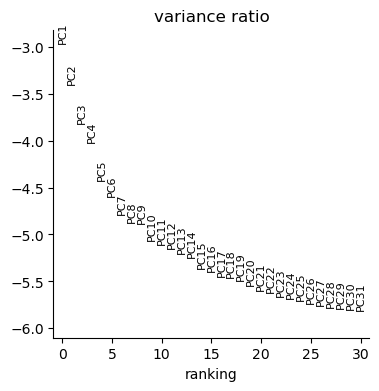

In [44]:
#plot elbow plot to determine the number of PCs to use for downstream analysis
sc.pl.pca_variance_ratio(filtered_rna, log=True)


## Running SEACells

As a rule of thumb, we recommended choosing one metacell for every 75 single-cells. Since this dataset contains ~7k cells, we choose 90 metacells.

Note 1: Running SEACells modifies the input Anndata object and adds the SEACell metacell assignments to the obs dataframe in the anndata object. Note 2: This analysis takes approxmiately 5 minutes



In [45]:
#computing number of metacells for every 75 single cells 
filtered_rna.n_obs / 75

1240.84

In [ ]:
#SEACells is memory-bound on very large inputs, so fit on a reproducible subsample to avoid MemoryError
seacell_max_cells = filtered_rna.n_obs  # set to the number of cells in the dataset to use all cells for SEACells fit
if filtered_rna.n_obs > seacell_max_cells:
    rng = np.random.default_rng(0)
    seacell_ix = rng.choice(filtered_rna.n_obs, size=seacell_max_cells, replace=False)
    seacell_rna = filtered_rna[seacell_ix].copy()
    print(f"Subsampling {filtered_rna.n_obs} cells to {seacell_max_cells} for SEACells fit")
else:
    seacell_rna = filtered_rna.copy()
    print(f"Using all {seacell_rna.n_obs} cells for SEACells fit")

#core parameters
n_SEACells = filtered_rna.n_obs // 75
build_kernel_on = 'X_pca'

#additional parameters
n_waypoint_eigs = 10

Using all 93063 cells for SEACells fit


In [ ]:
#convergence epsilon is set to a small value to ensure that the algorithm stops when the improvement in the fit becomes smaller than the specified threshold. This helps to prevent overfitting and ensures that the algorithm converges to a stable solution.

model = SEACells.core.SEACells( seacell_rna, 
                            build_kernel_on=build_kernel_on,
                            n_SEACells=n_SEACells, 
                            n_waypoint_eigs=n_waypoint_eigs, 
                            convergence_epsilon=1e-5)

Welcome to SEACells!


In [48]:
model.construct_kernel_matrix()
M = model.kernel_matrix
print(M.shape)
print(type(M))

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/93063 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/93063 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/93063 [00:00<?, ?it/s]

Constructing CSR matrix...
(93063, 93063)
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
#sns.clustermap(M, cmap='viridis')
#sns.clustermap(M.toarray()[500:500])

In [49]:
# Initialize archetypes
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 921 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 19/19 [00:02<00:00,  8.97it/s]

Selecting 9 cells from greedy initialization.


In [ ]:
# Fit the model to identify SEACells (using the subsampled data to avoid memory issues)
model.fit(min_iter=10, max_iter= 50)

Randomly initialized A matrix.


MemoryError: Unable to allocate 64.5 GiB for an array with shape (93063, 93063) and data type float64

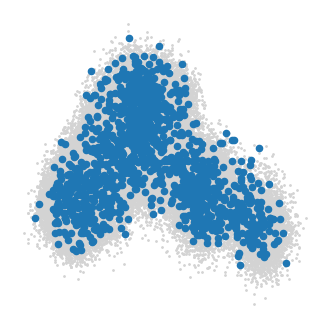

In [18]:
#Plot the initialization to ensure they are spread across phenotypic space
SEACells.plot.plot_initialization(seacell_rna, model, plot_basis='X_pca')

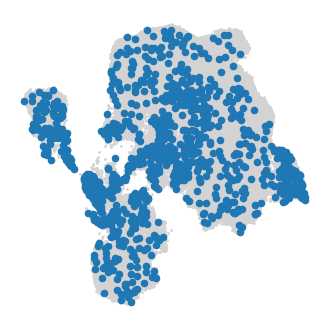

In [19]:
SEACells.plot.plot_initialization(seacell_rna, model, plot_basis='X_umap')

## Accessing results after running SEACells successfully

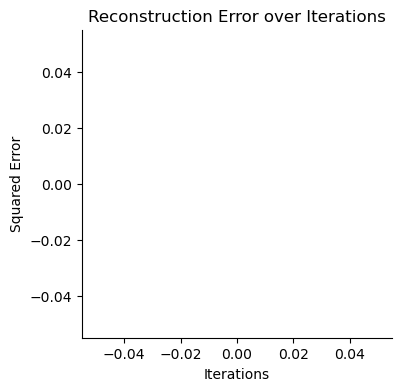

In [14]:
# Check for convergence 
model.plot_convergence()



In [13]:
#cells assigned to each SEACell
model.get_hard_assignments().head()



AttributeError: 'NoneType' object has no attribute 'argmax'

In [15]:
#The majority of single-cells are assigned to no more than 4 SEACells, and the strength of the top 5 strongest assignments is generally high, suggesting that the SEACells are well-defined and distinct from each other.
plt.figure(figsize=(3,2))
sns.distplot((model.A_.T > 0.1).sum(axis=1), kde=False)
plt.title(f'Non-trivial (> 0.1) assignments per cell')
plt.xlabel('# Non-trivial SEACell Assignments')
plt.ylabel('# Cells')
plt.show()

plt.figure(figsize=(3,2))
b = np.partition(model.A_.T, -5)    
sns.heatmap(np.sort(b[:,-5:])[:, ::-1], cmap='viridis', vmin=0)
plt.title('Strength of top 5 strongest assignments')
plt.xlabel('$n^{th}$ strongest assignment')
plt.show()





AttributeError: 'NoneType' object has no attribute 'T'

<Figure size 300x200 with 0 Axes>

In [21]:

labels,weights = model.get_soft_assignments()
labels.head()

AttributeError: 'NoneType' object has no attribute 'argmax'

## Summarizing data

In [17]:


SEACell_ad = SEACells.core.summarize_by_SEACell(seacell_rna, SEACells_label='SEACell', summarize_layer='raw')
SEACell_ad



KeyError: 'SEACell'

In [71]:
sc.pp.normalize_total(SEACell_ad)
sc.pp.log1p(SEACell_ad)

/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/SEACells/plot.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby('SEACell').mean().reset_index()
/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


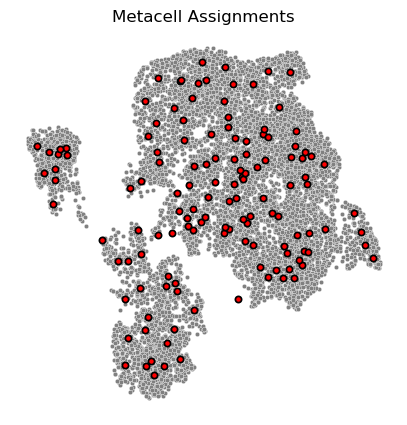

In [73]:
SEACells.plot.plot_2D(seacell_rna, key='X_umap', colour_metacells=False)

/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/SEACells/plot.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby('SEACell').mean().reset_index()
/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


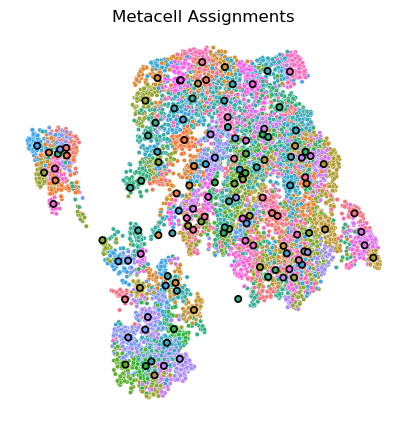

In [74]:
SEACells.plot.plot_2D(seacell_rna, key='X_umap', colour_metacells=True)

/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/SEACells/plot.py:121: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(label_df.groupby('SEACell').count().iloc[:, 0], bins=bins)


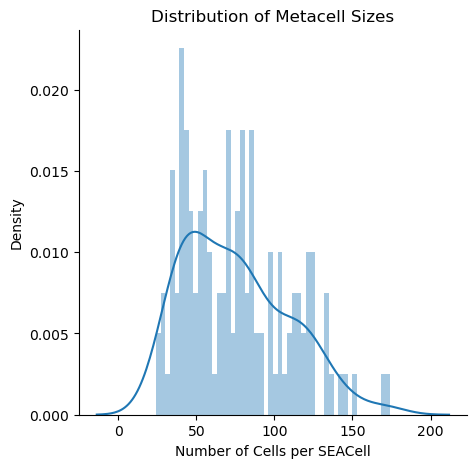

,size
SEACell,
SEACell-0,33
SEACell-1,56
SEACell-10,101
SEACell-100,64
SEACell-101,80
...,...
SEACell-95,174
SEACell-96,34
SEACell-97,56


In [79]:
SEACells.plot.plot_SEACell_sizes(seacell_rna, bins=50)